# 📘 Day 26 — Eigenvalues & Eigenvectors

## 🎯 Learning Objectives
- Understand eigenvalues and eigenvectors conceptually
- Learn how matrices transform vectors
- Compute eigenvalues and eigenvectors using NumPy
- Build intuition for why they matter in AI (PCA, stability, etc.)

## 🌍 Real-World Intuition
Imagine applying a transformation (like rotation + scaling) to a set of points.
Most vectors change direction, BUT some special vectors only get scaled — they don't change direction.

👉 These special vectors are called **Eigenvectors**
👉 The scaling factor is called **Eigenvalues**

**AI Connection:**
- PCA uses eigenvectors to find directions of max variance
- Used in dimensionality reduction, image compression, recommendation systems

### Eigenvectors help answer:

“Which directions in my data are the most important?”

👉 Eigenvectors = directions of meaningful patterns
👉 Eigenvalues = strength of those patterns

💡 Relatable Analogy
Imagine a crowd moving:
Random directions → noise
One dominant direction → trend

👉 Eigenvector = trend direction
👉 Eigenvalue = how strong the trend is

Think like this:

👉 Data = cloud of points
👉 Eigenvectors = main axes of that cloud
👉 Eigenvalues = importance of each axis

So eigenvectors tell AI:

“Look in THIS direction — that’s where the real signal is

1. PCA (Dimensionality Reduction) — Biggest Use Case

Imagine you have a dataset with many features.

Example:

Height
Weight
Age
Income
Spending

Some of these are correlated.

👉 PCA uses eigenvectors to find:
Direction where data varies the most → 1st principal component
Next most important direction → 2nd component

💡 Logic:
Eigenvector = direction of maximum information
Eigenvalue = how much information (variance)

👉 So instead of 100 features → you keep only top 2–3 eigenvectors

🚀 Result:
Faster models
Less noise
Better generalization

## 🧠 Task 1: Create a Matrix

In [3]:
# TODO: Create a 2x2 matrix
import numpy as np
A = np.array([[3,7], [5,-8]])

# TODO: Print the matrix
print('A=\n', A)

A=
 [[ 3  7]
 [ 5 -8]]


## 🧠 Task 2: Compute Eigenvalues & Eigenvectors

In [8]:
# TODO: Use numpy.linalg.eig() to compute eigenvalues and eigenvectors

#Eigenvalues → scaling factors

#Eigenvectors → special directions

eigenvalue, eigenvector = np.linalg.eig(A)
# TODO: Print eigenvalues
print('eigenvalue=\n', eigenvalue)
# TODO: Print eigenvectors
print('eigenvector=\n', eigenvector)

eigenvalue=
 [  5.57774721 -10.57774721]
eigenvector=
 [[ 0.9383953  -0.45823608]
 [ 0.34556369  0.88883052]]


## 🧠 Task 3: Verify the Eigen Equation
Formula: A * v = λ * v

In [11]:
# TODO: Select one eigenvector v and eigenvalue λ
v = [0.9383953, 0.34556369]
λ =  5.57774721
# TODO: Compute A @ v
A_v = np.dot(A, v)
print('A_v=', A_v)
# TODO: Compute λ * v
λ_v = np.dot(λ, v)
print('λ_v=', λ_v)
# TODO: Check if both are approximately equal
#Matrix = “machine” that distorts space
#Eigenvectors = directions that machine treats cleanly
#Eigenvalues = how strongly it acts on those directions

A_v= [5.23413173 1.92746698]
λ_v= [5.23413177 1.92746691]


## 🧠 Task 4: Visualize Transformation

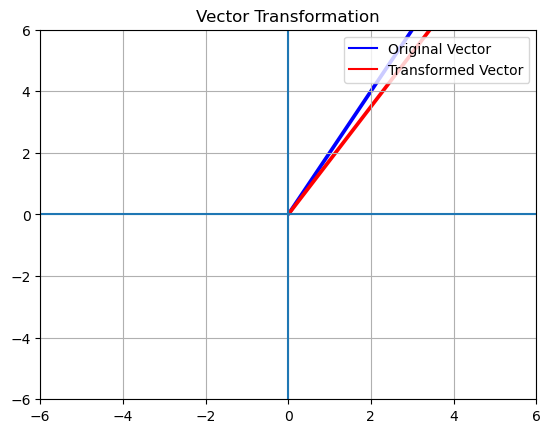

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix
A = np.array([[2, 1],
              [1, 3]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Choose vector

# 👉 Try this first (clear difference)
v = np.array([1, 2])

# 👉 Then try eigenvector
#v = eigenvectors[:, 0]

# Apply transformation
transformed_v = A @ v

# 🔥 Scale vectors for visibility
scale = 5
v_scaled = v * scale
transformed_scaled = transformed_v * scale

# Plot
plt.figure()

# Original vector (blue)
plt.quiver(0, 0, v_scaled[0], v_scaled[1],
           angles='xy', scale_units='xy', scale=1,
           color='blue')

# Transformed vector (red)
plt.quiver(0, 0, transformed_scaled[0], transformed_scaled[1],
           angles='xy', scale_units='xy', scale=1,
           color='red')

# Axis settings (important fix)
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.axhline(0)
plt.axvline(0)

plt.grid()
plt.title("Vector Transformation")

# Proper legend
plt.plot([], [], color='blue', label='Original Vector')
plt.plot([], [], color='red', label='Transformed Vector')
plt.legend()

plt.show()

## 🚀 Mini Project: Principal Direction Finder (Mini PCA)

🎯 Goal: Find the direction (eigenvector) along which data varies the most

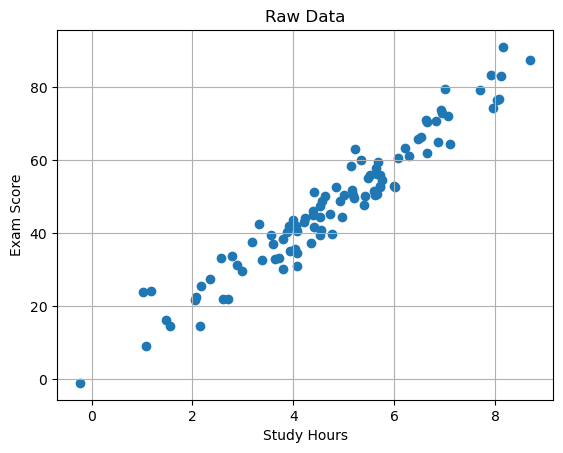

Covariance matrix:
 [[  3.29907957  31.80925382]
 [ 31.80925382 329.01423131]]
Eigenvalues:
 [2.21672253e-01 3.32091639e+02]
Eigenvectors:
 [[-0.99535274 -0.09629606]
 [ 0.09629606 -0.99535274]]
max_index:
 1
principal_vector:
 [-0.52573111 -0.85065081]


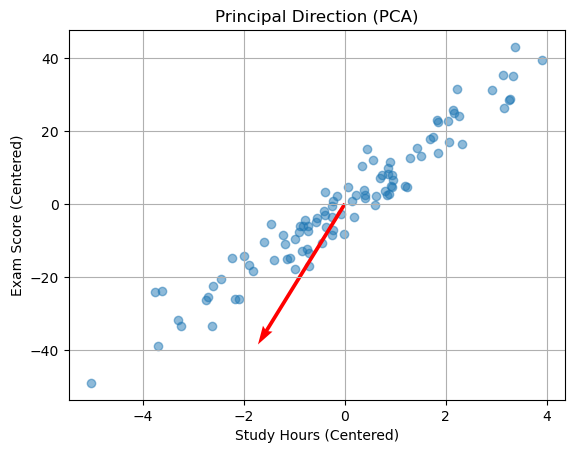

In [47]:
import numpy as np
import matplotlib.pyplot as plt
#Imagine:
#👉 Feature 1 = Study Hours
#👉 Feature 2 = Exam Score

# Step 1: Create a 2D dataset
# TODO: Create random 2D data
#5 (loc): The mean or "center" of the distribution. The generated numbers will cluster around this value.
#2 (scale): The standard deviation or "spread" of the distribution. A larger value results in numbers farther from the mean.
#100 (size): The shape of the output array, in this case, a 1-dimensional array containing 100 samples. 


np.random.seed(42)
study_hours = np.random.normal(5, 2, 100)

exam_score = study_hours * 10 + np.random.normal(0, 5, 100)

X = np.column_stack((study_hours, exam_score))
#print(X)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Raw Data")
plt.grid()
plt.show()
# Step 2: Center the data (subtract mean)
# TODO: Center data
# Now data is centered around (0,0)
mean = np.mean(X, axis = 0)
X_centered = X - mean

# Step 3: Compute covariance matrix
# TODO: Compute covariance matrix
cov_matrix = np.cov(X_centered.T)
print("Covariance matrix:\n",cov_matrix)
#This tells how features vary together
# Step 4: Compute eigenvalues & eigenvectors
# TODO: Apply np.linalg.eig()
#Covariance matrix shape:

# [[ small , large ]
#  [ large , huge ]]
# 👉 Means:

# One dominant direction exists
# Perfect case for PCA
#     This tells your model:
# Features are not independent
# You can reduce dimensions safely
# 👉 PCA will compress this into 1 feature

#     Positive covariance:
# Variables move together
# Study more → score increases ✅
# 👉 Magnitude is large:
# Strong relationship
# Not random data

eigenvalue, eigenvector = np.linalg.eig(cov_matrix)
print("Eigenvalues:\n", eigenvalue)
print("Eigenvectors:\n", eigenvector)
# Step 5: Identify principal component (largest eigenvalue)
# TODO: Find index of largest eigenvalue
max_index = np.argmax(eigenvalue)
print("max_index:\n", max_index)

# TODO: Extract corresponding eigenvector
principal_vector = eigenvectors[:, max_index]
print("principal_vector:\n", principal_vector)
# Step 6: Visualize data and principal direction
# TODO: Plot data points
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5)

# Draw principal vector
plt.quiver(0, 0,
           principal_vector[0],
           principal_vector[1],
           scale=3,
           color='red')

plt.xlabel("Study Hours (Centered)")
plt.ylabel("Exam Score (Centered)")
plt.title("Principal Direction (PCA)")
plt.grid()
plt.show()
# TODO: Plot principal eigenvector as direction

## ✅ Expected Outcome
- You understand eigenvalues as scaling factors
- You understand eigenvectors as invariant directions
- You built a simple PCA intuition

## 💡 Reflection Questions
1. Why are eigenvectors important in dimensionality reduction?
2. What happens if all eigenvalues are zero?
3. How does this relate to neural networks or embeddings?

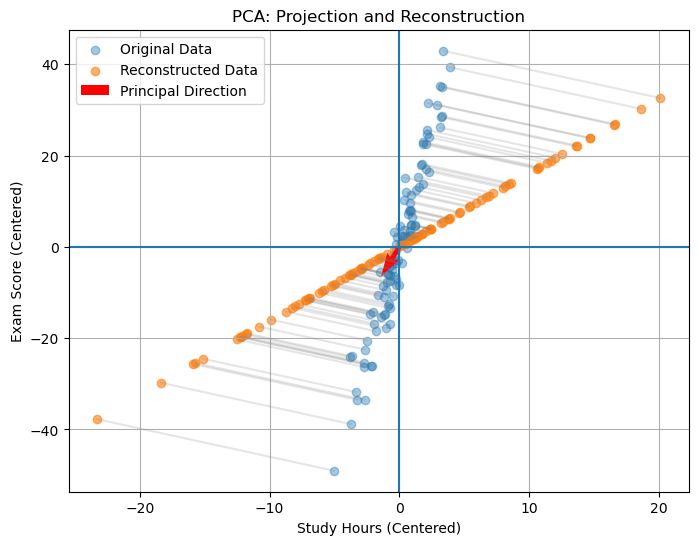

In [48]:
# Step 8: Project data onto principal direction (2D → 1D)
projection = X_centered @ principal_vector

# Step 9: Reconstruct data back to 2D
X_reconstructed = np.outer(projection, principal_vector)

# Step 10: Plot everything
plt.figure(figsize=(8, 6))

# Original data (blue)
plt.scatter(X_centered[:, 0], X_centered[:, 1],
            alpha=0.4, label='Original Data')

# Reconstructed data (green)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            alpha=0.6, label='Reconstructed Data')

# Draw principal direction (red line)
scale = 5
plt.quiver(0, 0,
           principal_vector[0]*scale,
           principal_vector[1]*scale,
           color='red', label='Principal Direction')

# Draw projection lines (optional but powerful)
for i in range(len(X_centered)):
    plt.plot([X_centered[i, 0], X_reconstructed[i, 0]],
             [X_centered[i, 1], X_reconstructed[i, 1]],
             color='gray', alpha=0.2)

# Axis
plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.xlabel("Study Hours (Centered)")
plt.ylabel("Exam Score (Centered)")
plt.title("PCA: Projection and Reconstruction")

plt.legend()
plt.show()